In [23]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path.cwd().resolve()
if (base / 'src').exists():
    ROOT = base
elif (base / 'research' / 'src').exists():
    ROOT = base / 'research'
elif (base.parent / 'src').exists():
    ROOT = base.parent
else:
    raise RuntimeError('Cannot locate research/src directory from current working directory')

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

plt.style.use('seaborn-v0_8-whitegrid')

from dynamics import anneal_bundle_max, CostConfig, rollout, bolza_cost

In [2]:
best_u_opt = pd.read_csv('best_u.csv', index_col='step').values

In [16]:
cfg = CostConfig()
eps = 0.05
rng = np.random.default_rng(42)
x0_base = np.zeros(6)
S = 50
initial_states = x0_base + rng.uniform(-eps, eps, size=(S, 6))

# Compute

In [ ]:
cfg.terminal_penalty = 5.0
best_u_max, best_j, trace = anneal_bundle_max(initial_states, best_u_opt, cfg,t0=100.0, seed=48)

control_names = ['u1_roll', 'u2_pitch', 'u3_yaw', 'u4_thrust']

df_max = pd.DataFrame(best_u_max, columns=control_names)
df_max.index.name = 'step'

print(df_max.to_string())
print(f"J максимальное по пучку = {best_j:.4f}")

df_max.to_csv('best_u_max_bundle.csv')

df_states = pd.DataFrame(initial_states)
df_states.to_csv('initial_states_max.csv')

       u1_roll  u2_pitch    u3_yaw  u4_thrust
step                                         
0     0.028164 -0.189551  0.057019  11.159863
1    -0.163644 -0.078026  0.213826  10.881211
2    -0.077517 -0.471071 -0.167535  11.701357
3    -0.026104  0.491300 -0.229960  11.650443
4    -0.221724  0.338751 -0.019628  11.476857
5    -0.067822  0.194031 -0.094155  11.907179
6     0.211593  0.194663 -0.222416  11.511267
7    -0.153110 -0.213541 -0.230529   8.854182
8     0.040923  0.112637 -0.261340   8.942733
9    -0.180020  0.251166 -0.065010  10.261828
10    0.240012  0.044977 -0.248407   9.604078
11    0.087949  0.219971  0.261799   3.075639
12    0.082317 -0.132426 -0.050745  11.881298
13    0.160146 -0.210701  0.098707  11.380855
14   -0.032903 -0.289675 -0.199741  10.136056
J максимальное по пучку = 9.7105


In [33]:
initial_states = pd.read_csv('initial_states_max.csv', index_col=0).values
best_u_max = pd.read_csv('best_u_max_bundle.csv', index_col='step').values

In [34]:
bundle_states = []
bundle_scores = []

for x0 in initial_states:
    X_k = rollout(x0, best_u_max, cfg.dt)
    score_k = bolza_cost(x0, best_u_max, cfg)
    bundle_states.append(X_k)
    bundle_scores.append(score_k)

bundle_states = np.array(bundle_states)
bundle_scores = np.array(bundle_scores)

# Visualization

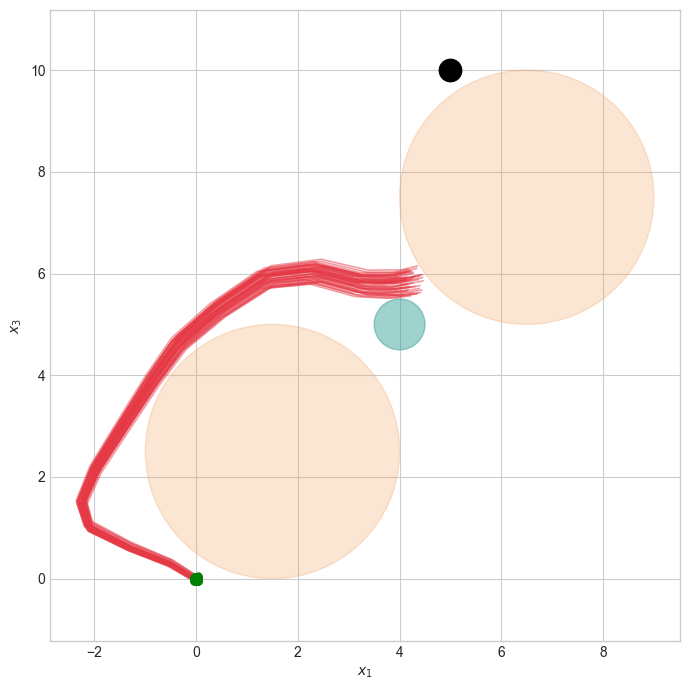

In [35]:
fig, ax = plt.subplots(figsize=(7, 7))

for X_k in bundle_states:
    ax.plot(X_k[:, 0], X_k[:, 2], linewidth=1.2, alpha=0.5, color="#E63946")

ax.scatter(initial_states[:, 0], initial_states[:, 2],
           s=25, color="green", zorder=5)

for cyl in cfg.cylinders:
    ax.add_patch(plt.Circle((cyl.x, cyl.z), cyl.radius, color='#F4A261', alpha=0.28))

for wnd in cfg.windows:
    ax.add_patch(plt.Circle((wnd.x, wnd.z), wnd.radius, color='#2A9D8F', alpha=0.45))

ax.scatter([cfg.terminal_state[0]], [cfg.terminal_state[2]],
           marker='o', s=260, color='black', zorder=6)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_3$')
ax.axis('equal')
plt.tight_layout()
plt.show()

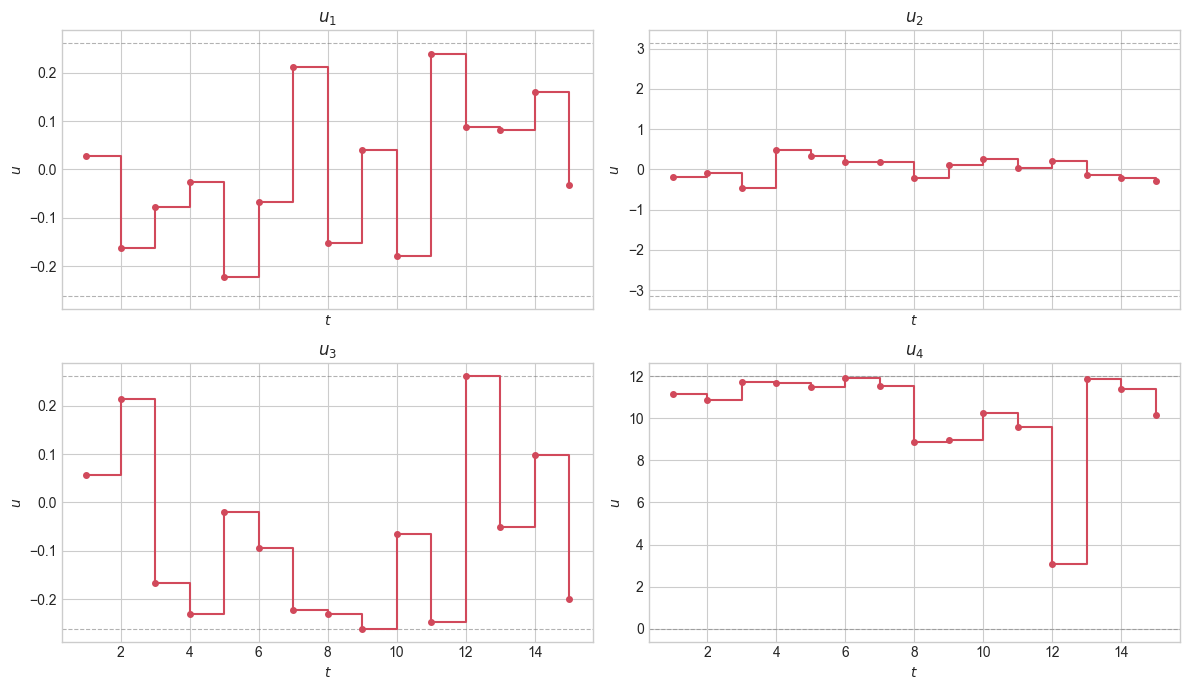

In [36]:
control_names  = ['$u_1$', '$u_2$', '$u_3$',  '$u_4$']
control_limits = [
    (-np.pi/12, np.pi/12),
    (-np.pi,    np.pi),
    (-np.pi/12, np.pi/12),
    (0.0,       12.0),
]

steps = np.arange(1, best_u_max.shape[0] + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

for j, ax in enumerate(axes.ravel()):
    lo, hi = control_limits[j]
    ax.axhline(lo, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axhline(hi, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.step(steps, best_u_max[:, j], where='post', color='#D1495B', linewidth=1.5)
    ax.plot(steps, best_u_max[:, j], 'o', color='#D1495B', markersize=4)
    ax.set_title(control_names[j])
    ax.set_xlabel('$t$')
    ax.set_ylabel('$u$')

plt.tight_layout()
plt.show()